In [12]:
%matplotlib widget

# ── Imports ───────────────────────────────────────────────────────────────────
import datetime as dt
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

In [13]:
# ── Configuration ─────────────────────────────────────────────────────────────

ARCHIVER_URL = "http://lcls-archapp.slac.stanford.edu/retrieval/data/getData.json"
TIMEOUT_SECONDS = 20.0
LOCAL_TZ = ZoneInfo("America/Los_Angeles")

# PVs available in the viewer.
# Each entry: display label -> (pv_name, y-axis label)
PV_DEFS = {
    "GMD — Pulse Energy (SXR)":      ("EM1K0:GMD:HPS:milliJoulesPerPulse",  "Energy (mJ)"),
    "XGMD — Pulse Energy (SXR)":     ("EM2K0:XGMD:HPS:milliJoulesPerPulse", "Energy (mJ)"),
    "GDET 241 — Pulse Energy (HXR)": ("GDET:FEE1:241:ENRC",                 "Energy (mJ)"),
    "GDET 361 — Pulse Energy (HXR)": ("GDET:FEE1:361:ENRC",                 "Energy (mJ)"),
}


In [14]:
# ── Archive fetch ─────────────────────────────────────────────────────────────

def _to_utc_str(t: dt.datetime) -> str:
    """Convert a datetime to the ISO-8601 UTC string expected by the archiver."""
    if t.tzinfo is None:
        t = t.replace(tzinfo=LOCAL_TZ)
    return t.astimezone(dt.timezone.utc).strftime("%Y-%m-%dT%H:%M:%S.000Z")


def fetch_pv(pv_name: str, hours_back: float = 1.0):
    """
    Fetch archived data for *pv_name* covering the last *hours_back* hours.

    Returns
    -------
    timestamps : list[datetime]
    values     : np.ndarray (float)
    """
    now = dt.datetime.now(LOCAL_TZ)
    start = now - dt.timedelta(hours=hours_back)

    response = requests.get(
        ARCHIVER_URL,
        params={"pv": pv_name, "from": _to_utc_str(start), "to": _to_utc_str(now)},
        timeout=TIMEOUT_SECONDS,
    )
    response.raise_for_status()

    payload = response.json()
    if not payload or "data" not in payload[0]:
        raise RuntimeError(f"No data returned for PV: {pv_name}")

    data = payload[0]["data"]
    secs = np.array([d["secs"] + d.get("nanos", 0) * 1e-9 for d in data])
    vals = np.array([d["val"] for d in data], dtype=float)

    # Convert UNIX epoch → aware datetime objects for matplotlib
    timestamps = [
        dt.datetime.fromtimestamp(s, tz=LOCAL_TZ) for s in secs
    ]
    return timestamps, vals

In [15]:
# ── Plot helper ───────────────────────────────────────────────────────────────

def plot_pv(label: str, hours_back: float):
    """
    Fetch and plot the PV identified by *label* (a key in PV_DEFS).
    Returns a matplotlib Figure.
    """
    pv_name, y_label = PV_DEFS[label]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(y_label)
    ax.set_xlabel("Time (local)")

    try:
        timestamps, values = fetch_pv(pv_name, hours_back=hours_back)
        ax.plot(timestamps, values, linewidth=0.8, color="steelblue")
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%H:%M", tz=LOCAL_TZ)
        )
        fig.autofmt_xdate(rotation=30)
    except Exception as exc:
        ax.text(0.5, 0.5, f"Error fetching data:\n{exc}",
                ha="center", va="center", transform=ax.transAxes,
                color="firebrick", fontsize=9)

    fig.tight_layout()
    return fig

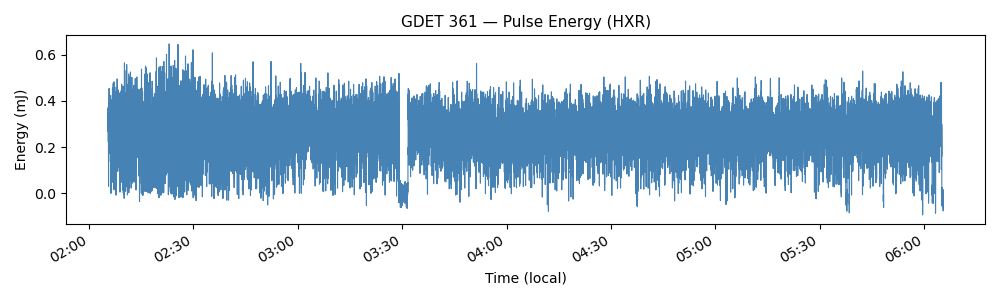

In [16]:
# ── Plot (with matplotlib widget interactivity) ───────────────────────────────
# Uses built-in interactivity from %matplotlib widget magic: zoom, pan, reset, save

fig = plot_pv(list(PV_DEFS.keys())[3], hours_back=4.0)
plt.show()

In [6]:
import ipympl, matplotlib
print("ipympl:", ipympl.__version__)
print("backend:", matplotlib.get_backend())

ipympl: 0.10.0
backend: widget
